In [16]:
import torch
import torch.nn as nn
import torch_optimizer as optim_look  # Using RAdam
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from minisom import MiniSom
import numpy as np
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from tqdm import tqdm

In [26]:
class straxCoder(nn.Module):
    def __init__(self, input_dim=784, latent_dim=64):
        super(straxCoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, latent_dim),
            nn.Tanh()
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

    def embed(self, x):
        return self.encoder(x)

In [19]:
input_size = 784
latent_size = 64
learning_rate = 0.001
batch_size = 256
epochs = 20

# SOM Hyperparameters
som_grid_rows = 15
som_grid_cols = 15
sigma = 1.0
learning_rate_som = 0.5
num_iterations = 10000


In [28]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))
])
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = straxCoder(input_size, latent_size).to(device)
criterion = nn.SmoothL1Loss()
optimizer = optim_look.RAdam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

In [24]:
# Early Stopping Parameters
patience = 5
best_loss = float('inf')
epochs_no_improve = 0

model.train()
for epoch in range(epochs):
    total_loss = 0
    for data, _ in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs}"):
        data = data.to(device)
        recon = model(data)
        loss = criterion(recon, data)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch [{epoch + 1}/{epochs}] - Loss: {avg_loss:.4f}")

    # Early Stopping Check
    if avg_loss < best_loss - 1e-6:
        best_loss = avg_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {epoch + 1}")
            break

Epoch 1/20: 100%|██████████| 235/235 [00:16<00:00, 13.97it/s]


Epoch [1/20] - Loss: 0.0394


Epoch 2/20: 100%|██████████| 235/235 [00:16<00:00, 14.07it/s]


Epoch [2/20] - Loss: 0.0107


Epoch 3/20: 100%|██████████| 235/235 [00:16<00:00, 13.88it/s]


...

Epoch [18/20] - Loss: 0.0020


Epoch 19/20: 100%|██████████| 235/235 [00:17<00:00, 13.82it/s]


Epoch [19/20] - Loss: 0.0020


Epoch 20/20: 100%|██████████| 235/235 [00:16<00:00, 13.83it/s]

Epoch [20/20] - Loss: 0.0020


In [30]:
model.eval()
all_embeddings, all_labels = [], []
with torch.no_grad():
    for data, labels in train_loader:
        data = data.to(device)
        embeddings = model.embed(data)
        all_embeddings.append(embeddings.cpu().numpy())
        all_labels.append(labels.numpy())

X = np.vstack(all_embeddings)
y = np.hstack(all_labels)

In [31]:
X_norm = normalize(X)

In [32]:
som = MiniSom(som_grid_rows, som_grid_cols, input_len=latent_size, sigma=sigma, learning_rate=learning_rate_som)
som.random_weights_init(X_norm)
som.train_random(X_norm, num_iterations)

# Map data points to SOM grid
som_clusters = np.zeros(len(X_norm), dtype=int)
for i, x in enumerate(X_norm):
    w = som.winner(x)
    som_clusters[i] = w[0] * som_grid_cols + w[1]

# -------------------------------
# Evaluation and Visualization
# -------------------------------
sil_score = silhouette_score(X_norm, som_clusters)
db_index = davies_bouldin_score(X_norm, som_clusters)
ch_index = calinski_harabasz_score(X_norm, som_clusters)
print(f"\nSOM Silhouette Score: {sil_score:.4f}")
print(f"SOM Davies-Bouldin Index: {db_index:.4f}")
print(f"SOM Calinski-Harabasz Index: {ch_index:.4f}")


SOM Silhouette Score: 0.0490
SOM Davies-Bouldin Index: 2.7993
SOM Calinski-Harabasz Index: 275.9270


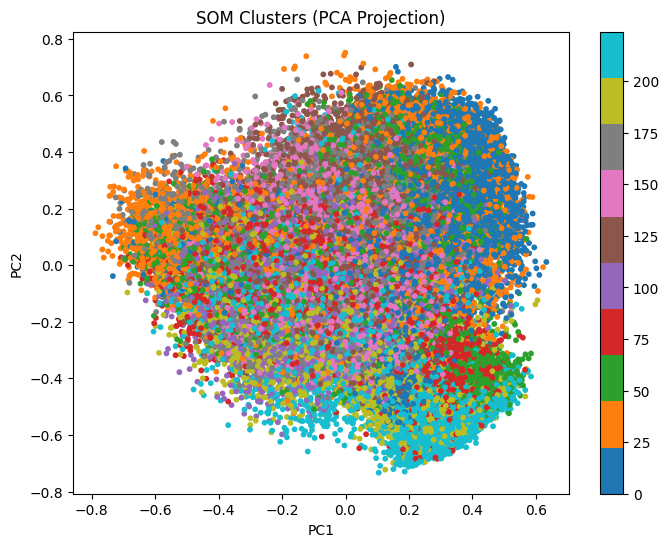

In [10]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_norm)

# Plot 1: SOM Clusters (PCA)
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=som_clusters, cmap='tab10', s=10)
plt.title("SOM Clusters (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar()
plt.show()

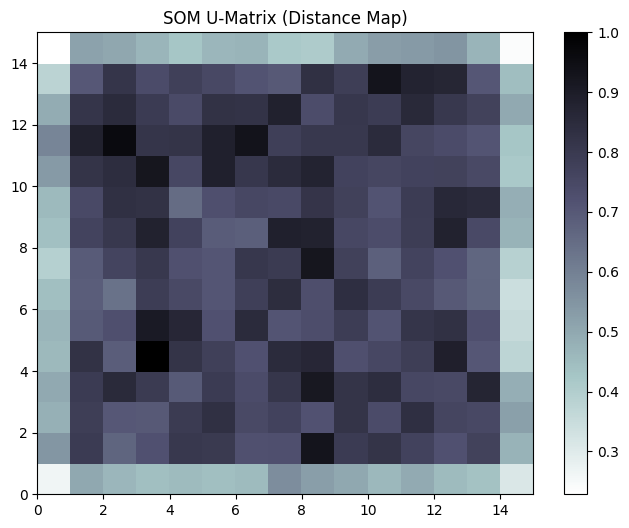

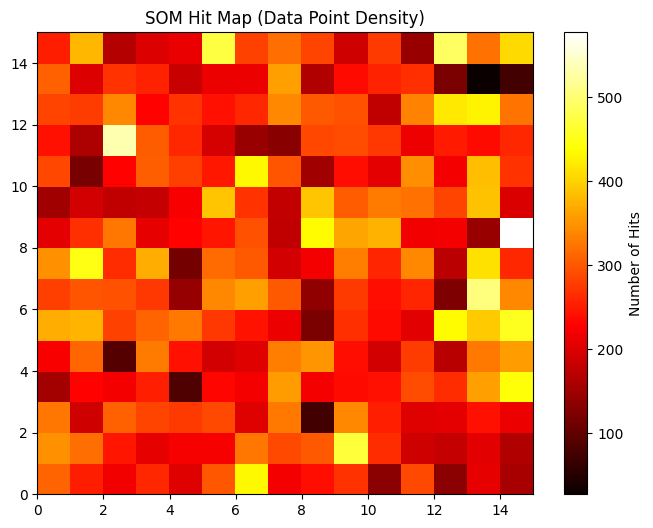

In [33]:
plt.figure(figsize=(8, 6))
plt.title("SOM U-Matrix (Distance Map)")
plt.pcolor(som.distance_map().T, cmap='bone_r')
plt.colorbar()
plt.show()

# Plot 4: Hit Map
plt.figure(figsize=(8, 6))
plt.title("SOM Hit Map (Data Point Density)")
hit_map = np.zeros((som_grid_rows, som_grid_cols))
for x in X_norm:
    w = som.winner(x)
    hit_map[w[0], w[1]] += 1
plt.pcolor(hit_map.T, cmap='hot')
plt.colorbar(label='Number of Hits')
plt.show()

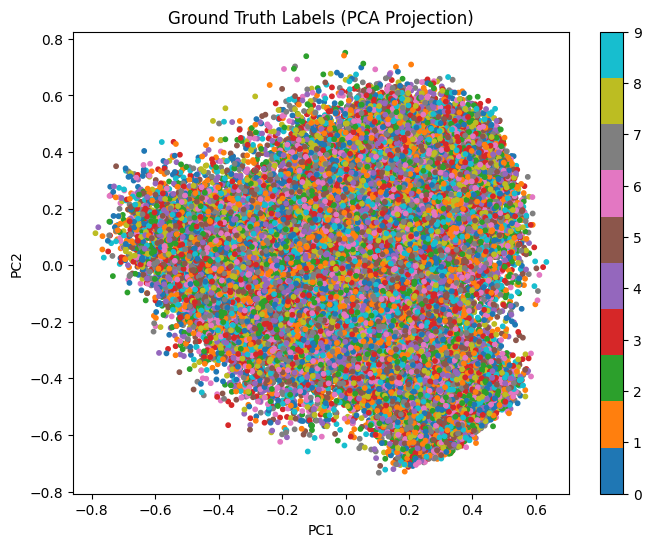

In [34]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', s=10)
plt.title("Ground Truth Labels (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar()
plt.show()

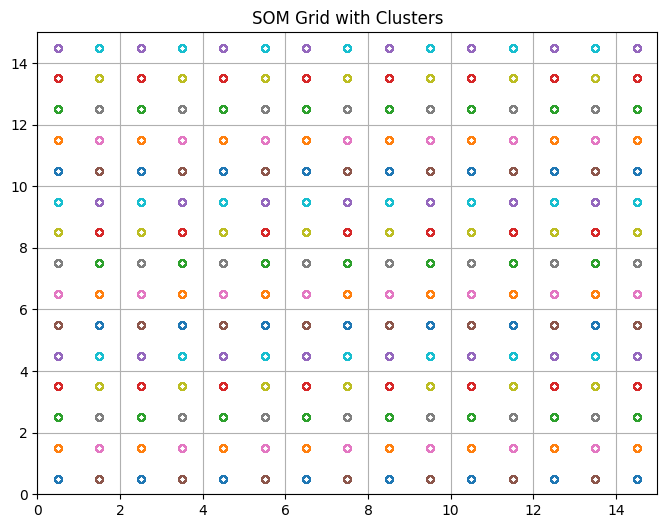

In [35]:
plt.figure(figsize=(8, 6))
plt.title("SOM Grid with Clusters")
for i, x in enumerate(X_norm):
    w = som.winner(x)
    plt.plot(w[0] + 0.5, w[1] + 0.5, 'o', markerfacecolor='None',
             markeredgecolor=plt.cm.tab10(som_clusters[i] % 10), markersize=5, markeredgewidth=1)
plt.xlim([0, som_grid_rows])
plt.ylim([0, som_grid_cols])
plt.grid()
plt.show()